## EDA ANALYSIS 

In [11]:
## Upload the csv file 
import os
import pandas as pd

# Define the path to the CSV file
csv_file_path = 'Reviews - Sheet1.csv'
customers_review = pd.read_csv(csv_file_path)
customers_review.head(10)


,Username,Rating,Review
0,pixel_planner_99,3,Can we get a pie chart for the categories? lol
1,bookworm99,3,Category summary math is adding expenses and i...
2,frosty_homecook,2,Fix the sorting! My $1000 rent shows up before...
3,noisyphotoggriffintown,2,Category summary is mathematically flawed.
4,snowyartisthochelaga,1,Sort button is broken!! Search is broken!! Sum...
5,chartNerdGang_438,1,Search breaks the app's list styling. Very ugly.
6,cashFlowMode,4,"Good start, but Iâ€™d love to see support for ..."
7,bagelTimeQuest.mtl,2,I entered my salary and my rent in the same ca...
8,rentCrunchClubmileend,2,Why does the category summary add my incmoe to...
9,ultrapoutinerosemont,3,Add an edit button and pie charts please. tbh


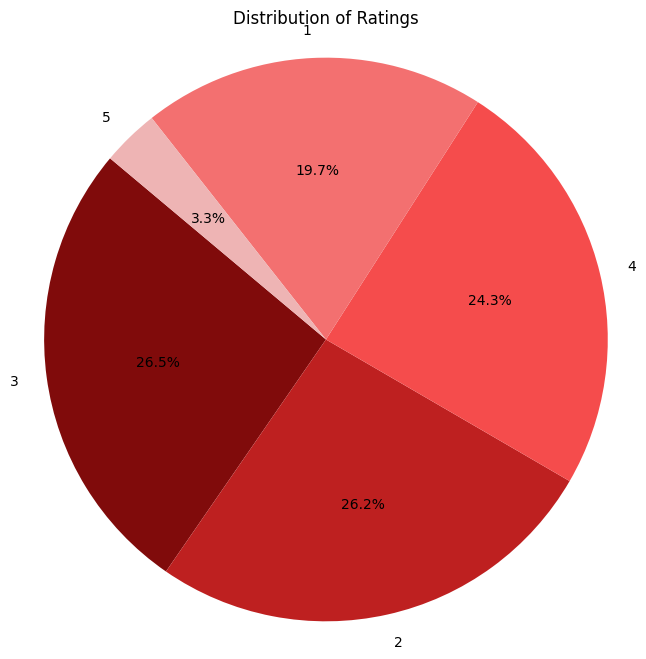

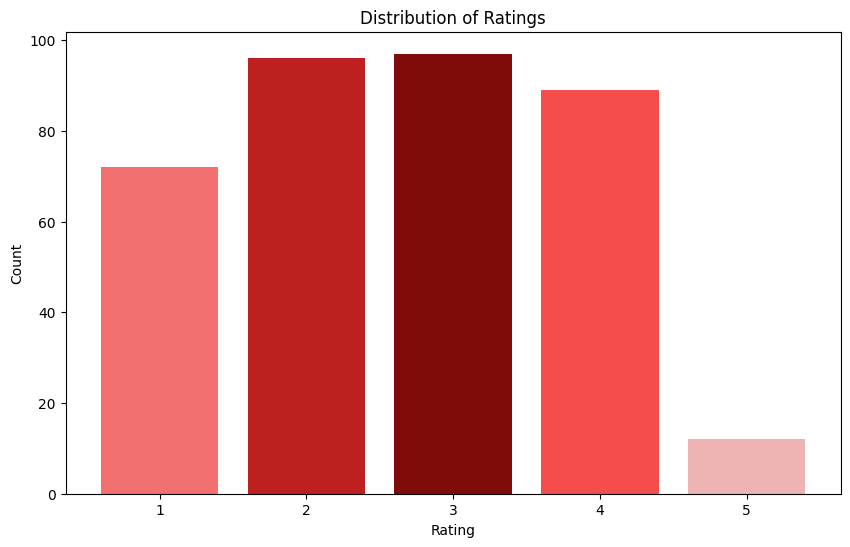

In [16]:
## Pie chart of the distribution of ratings
import matplotlib.pyplot as plt
# Count the occurrences of each rating
rating_counts = customers_review['Rating'].value_counts()
# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140, colors=["#800b0b","#be2020","#f54c4c","#f37070", "#eeb4b4"])
plt.title('Distribution of Ratings')
plt.axis('equal')  
plt.show()

## Create a bar chart of the distribution of ratings 
plt.figure(figsize=(10, 6))
plt.bar(rating_counts.index, rating_counts.values, color=["#800b0b","#be2020","#f54c4c","#f37070", "#eeb4b4"])
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings')
plt.xticks(rating_counts.index)
plt.show()



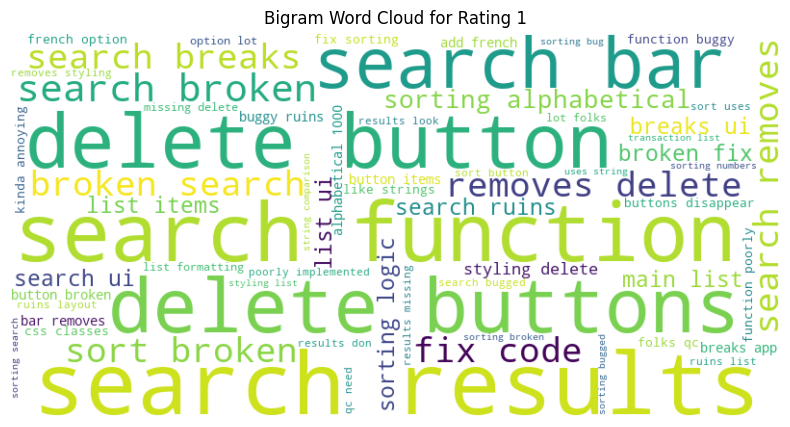

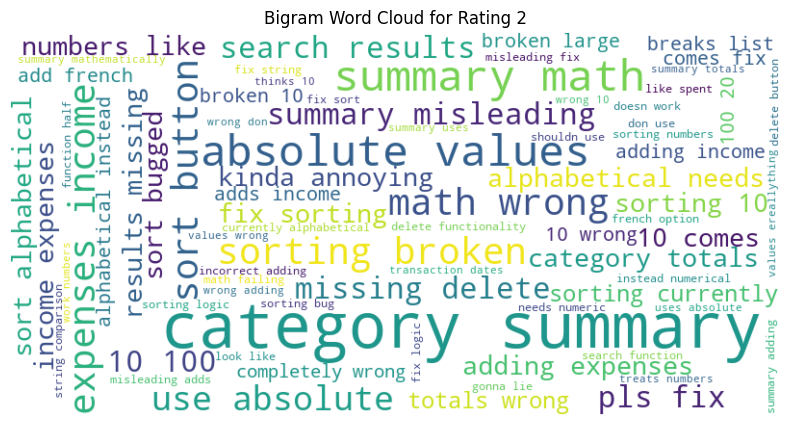

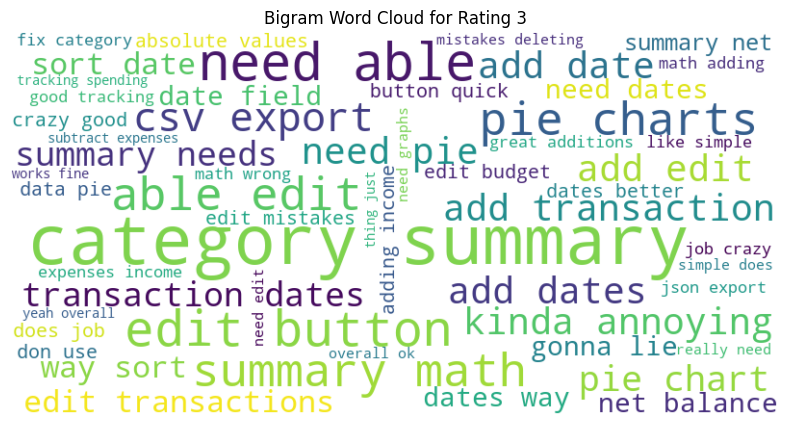

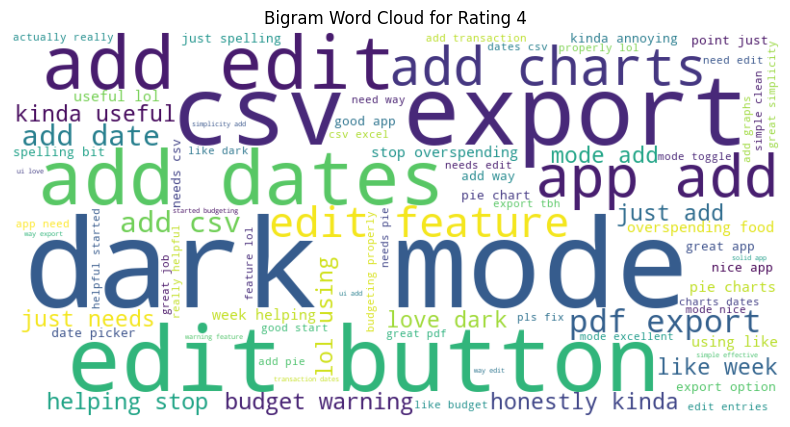

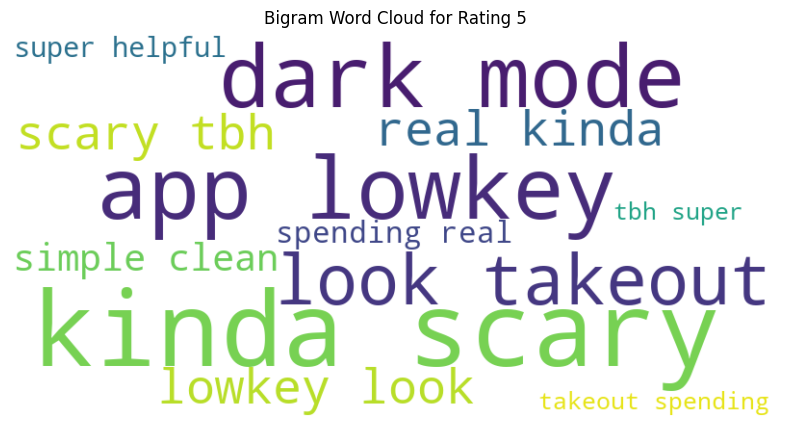

In [ ]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Function to generate a bigram word cloud for a specific rating
def generate_bigram_wordcloud(rating, max_words=100, min_freq=2):
    # Filter reviews for the given rating
    reviews = customers_review[customers_review['Rating'] == rating]['Review'].dropna()
    if reviews.empty:
        print(f"No reviews for rating {rating}")
        return

    # Use CountVectorizer to get bigram frequencies
    vectorizer = CountVectorizer(ngram_range=(2, 2),  stop_words='english')  
    X = vectorizer.fit_transform(reviews)
    freqs = X.toarray().sum(axis=0)
    vocab = vectorizer.get_feature_names_out()

    # Build a dict: {"two words": count}
    bigram_freq = {vocab[i]: freqs[i] for i in range(len(vocab))}

    # Optionally filter out very rare bigrams
    bigram_freq = {k: v for k, v in bigram_freq.items() if v >= min_freq}

    if not bigram_freq:
        print(f"No bigrams with frequency >= {min_freq} for rating {rating}")
        return

    # Create word cloud from frequencies
    wc = WordCloud(width=800,
                   height=400,
                   background_color='white',
                   colormap='viridis',
                   max_words=max_words)
    wc.generate_from_frequencies(bigram_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Bigram Word Cloud for Rating {rating}')
    plt.show()


# Generate bigram word clouds for each rating
for rating in sorted(customers_review['Rating'].unique()):
    generate_bigram_wordcloud(rating)


In [19]:
## Sentiment analysis of reviews
from textblob import TextBlob
# Function to calculate sentiment polarity
def calculate_sentiment(review):
    return TextBlob(review).sentiment.polarity
# Apply the function to the 'Review' column and create a new 'Sentiment' column
customers_review['Sentiment'] = customers_review['Review'].apply(calculate_sentiment)
# Display the first few rows of the DataFrame with the new 'Sentiment' column
customers_review.head(100)



,Username,Rating,Review,Sentiment
0,pixel_planner_99,3,Can we get a pie chart for the categories? lol,0.800000
1,bookworm99,3,Category summary math is adding expenses and i...,0.000000
2,frosty_homecook,2,Fix the sorting! My $1000 rent shows up before...,0.000000
3,noisyphotoggriffintown,2,Category summary is mathematically flawed.,-0.500000
4,snowyartisthochelaga,1,Sort button is broken!! Search is broken!! Sum...,-0.742188
...,...,...,...,...
95,nerd.verdun,3,"Works fine for basic stuff, not fancy, but it ...",0.208333
96,nightowlnerdgriffintown,3,Category summary should show the net balance.....,-0.400000
97,thrifty.gardener.griffin,3,Charts and an edit butotn would be great addit...,0.800000
98,spicyplantmomvilleray,3,"The colors are nice, but we need more visual d...",0.425000


C:\Users\sadiq\AppData\Local\Temp\ipykernel_64528\2613607490.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='Sentiment', data=customers_review, palette="Set3")


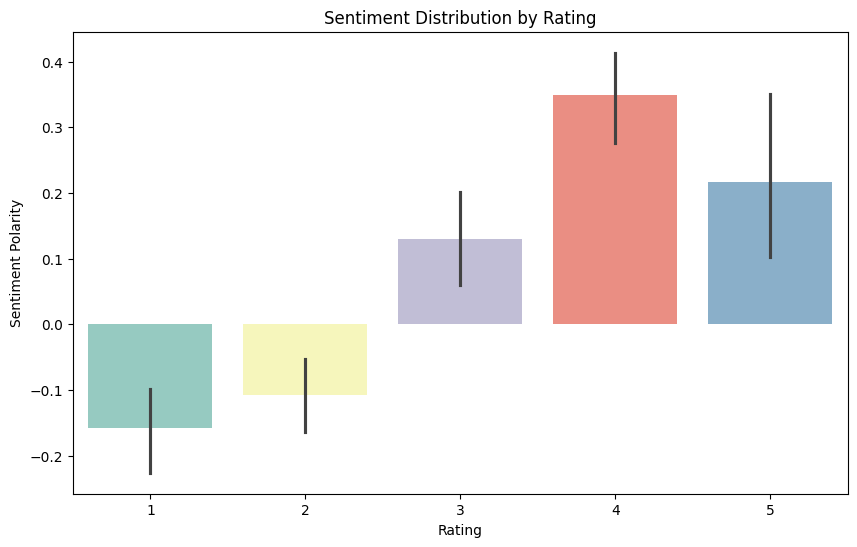

In [31]:
## Sentiment distribution by rating in bar chart
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x='Rating', y='Sentiment', data=customers_review, palette="Set3")
plt.title('Sentiment Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Sentiment Polarity')
plt.show()

C:\Users\sadiq\AppData\Local\Temp\ipykernel_64528\3658693870.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rating', y='Sentiment', data=customers_review, palette="Set3")


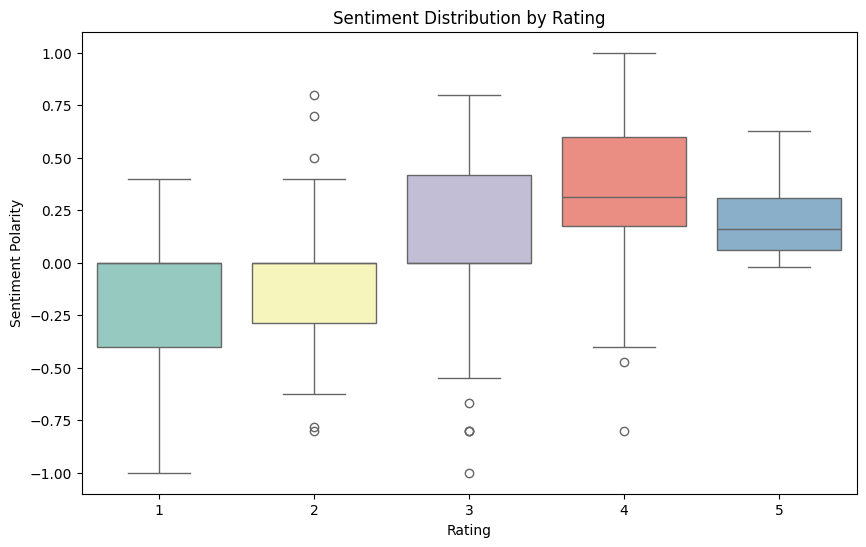

In [ ]:
## Semtiment distribution by rating
plt.figure(figsize=(10, 6))
sns.boxplot(x='Rating', y='Sentiment', data=customers_review, palette="Set3")
plt.title('Sentiment Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Sentiment Polarity')
plt.show()

In [ ]:
from sklearn.feature_extraction import text

# Your custom stop words
custom_stop_words = [
    'the', 'a', 'an', 'and', 'but', 'or', 'if', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against',
    'between', 'into', 'through', 'during', 'before', 'after', 'kinda',
    'above', 'below', 'actually', 'really', 'just', 'also', 'even', 'much', 'many', 'lot'
]

# Combine sklearn's English stop words with your custom list
stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_stop_words))

def get_common_words(rating, top_n=10):
    # Filter reviews for the given rating
    reviews = customers_review[customers_review['Rating'] == rating]['Review'].dropna().astype(str)
    if reviews.empty:
        print(f"No reviews for rating {rating}")
        return []

    # Use CountVectorizer to get word frequencies, excluding stop words
    vectorizer = CountVectorizer(stop_words=stop_words)
    X = vectorizer.fit_transform(reviews)

    # If all words were removed as stopwords, handle gracefully
    if X.shape[1] == 0:
        print(f"No informative words (all stopwords) for rating {rating}")
        return []

    freqs = X.toarray().sum(axis=0)
    vocab = vectorizer.get_feature_names_out()

    # Build a dict: {"word": count}
    word_freq = {vocab[i]: freqs[i] for i in range(len(vocab))}

    # Get the top N most common (non-stopword) words
    common_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return common_words

# Get and print the most important words (non-stopwords) for each rating
for rating in sorted(customers_review['Rating'].unique()):
    common_words = get_common_words(rating)
    print(f"Most common IMPORTANT words for rating {rating}:")
    for word, freq in common_words:
        print(f" {word}, {freq}")



Most common IMPORTANT words for rating 1:
 search, 48
 sorting, 21
 delete, 18
 broken, 16
 fix, 15
 list, 15
 sort, 12
 ui, 11
 breaks, 9
 button, 9
Most common IMPORTANT words for rating 2:
 summary, 35
 category, 28
 sorting, 28
 fix, 23
 wrong, 19
 sort, 18
 math, 15
 10, 13
 search, 12
 absolute, 11
Most common IMPORTANT words for rating 3:
 need, 28
 add, 24
 edit, 23
 category, 22
 summary, 20
 dates, 16
 charts, 14
 pie, 13
 csv, 11
 transactions, 11
Most common IMPORTANT words for rating 4:
 add, 36
 export, 20
 dark, 18
 edit, 18
 mode, 18
 app, 15
 csv, 15
 charts, 14
 great, 14
 lol, 13
Most common IMPORTANT words for rating 5:
 takeout, 5
 app, 4
 love, 4
 scary, 4
 helpful, 3
 simple, 3
 spending, 3
 super, 3
 awesome, 2
 budgeting, 2
